# Model Testing Notebook

This notebook is extracted from the model-testing part of `scratch.ipynb`.

Key behavior:
- It automatically reads `tet_quality_mode` from the run's `train_config.json` based on the checkpoint path.
- If missing (older runs), it falls back to `"mean_ratio"`.
- The detected quality metric is printed and used consistently during evaluation.


In [15]:
import os
import re
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from tet_mat73_loader import TetMat73Dataset
from tet_mesh_topology_local import TetMeshTopology
from tet_env import softmin_score, worstk_mean_score

from model_face_edge_gpt import Mesh3DActorCritic
from initial_embedding import batch_from_obs, model_action_to_env_with_sizes


In [16]:
def round_id_from_ckpt(path: str) -> int:
    m = re.search(r"model_round(\d+)\.pt", os.path.basename(path))
    return int(m.group(1)) if m else -1


def resolve_quality_mode_from_ckpt(ckpt_path: str, default_mode: str = "mean_ratio") -> str:
    run_dir = os.path.dirname(os.path.abspath(ckpt_path))
    cfg_path = os.path.join(run_dir, "train_config.json")
    mode = default_mode

    if os.path.exists(cfg_path):
        try:
            with open(cfg_path, "r", encoding="utf-8") as f:
                cfg = json.load(f)
            mode = str(cfg.get("tet_quality_mode", default_mode))
            print(f"Loaded train config: {cfg_path}")
        except Exception as e:
            print(f"Warning: failed to read {cfg_path}: {e}")
            mode = default_mode
    else:
        print(f"No train_config.json found near checkpoint. Fallback to default: {default_mode}")

    if mode not in ("mean_ratio", "simpqual1", "simpqual2"):
        print(f"Unknown tet_quality_mode '{mode}', fallback to {default_mode}")
        mode = default_mode

    print(f"Using tet quality metric: {mode}")
    return mode


def obs_from_topo(
    topo: TetMeshTopology,
    *,
    step: int,
    no_improve: int,
    max_steps: int,
    patience_eval: int,
) -> dict:
    return dict(
        points=topo.points,
        tets=topo.tets,
        faces=topo.faces,
        face2tet=topo.face2tet,
        edges=topo.edges,
        candidate_mask=topo.candidate_mask(),
        tet_quality=topo.tet_quality,
        step_frac=float(step) / float(max(1, max_steps)),
        no_improve_frac=float(no_improve) / float(max(1, patience_eval)),
    )


def score_from_quality(q: np.ndarray, score_mode: str, softmin_tau: float, worstk_k: int) -> float:
    if score_mode == "softmin":
        return softmin_score(q, tau=softmin_tau)
    if score_mode == "worstk":
        return worstk_mean_score(q, k=worstk_k)
    raise ValueError(score_mode)


def build_model_from_ckpt(ckpt_path: str, device: torch.device, example_obs: dict):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model" in ckpt:
        state = ckpt["model"]
        cfg = ckpt.get("run_config", {})
    else:
        state = ckpt
        cfg = {}

    bg0 = batch_from_obs([example_obs], device=device)
    d_edge_in = bg0.edge_feat.shape[-1]
    d_face_in = bg0.face_feat.shape[-1]

    model = Mesh3DActorCritic(
        d_edge_in=d_edge_in,
        d_face_in=d_face_in,
        d_h=int(cfg.get("d_h", 128)),
        num_layers=int(cfg.get("num_layers", 4)),
        msg_hidden=int(cfg.get("msg_hidden", 128)),
        value_hidden=int(cfg.get("value_hidden", 128)),
        critic_extra_dim=int(cfg.get("critic_extra_dim", bg0.quality_feat.shape[-1])),
        use_coord_update=False,
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(device)

    model.load_state_dict(state, strict=True)
    model.eval()
    return model


In [17]:
@torch.inference_mode()
def run_agent_until_stall(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    topo = TetMeshTopology(P, T_init.copy(), tet_quality_mode=tet_quality_mode)

    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
    best = cur
    best_tets = topo.tets.copy()
    no_improve = 0
    steps = 0
    step_rewards = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        step_rewards.append(float(cur - prev))

        if ok and (cur - best) >= eps_improve:
            best = cur
            best_tets = topo.tets.copy()
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    if fallback_final_to_best:
        topo = TetMeshTopology(P, best_tets, tet_quality_mode=tet_quality_mode)
        final_score = best
    else:
        final_score = cur

    return topo, best, final_score, steps, step_rewards


def evaluate_checkpoint(
    ckpt_path: str,
    ds: TetMat73Dataset,
    test_ids: np.ndarray,
    T_good: np.ndarray,
    device: torch.device,
    *,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    i0 = int(test_ids[0])
    P0, Tbad0 = ds.get(i0)
    topo0 = TetMeshTopology(P0, Tbad0, tet_quality_mode=tet_quality_mode)
    model = build_model_from_ckpt(
        ckpt_path,
        device,
        obs_from_topo(topo0, step=0, no_improve=0, max_steps=max_steps, patience_eval=patience_eval),
    )

    rows = []
    step_reward_trajs = []
    for i in tqdm(test_ids, desc=f"Eval {os.path.basename(ckpt_path)}", leave=False):
        P, Tbad = ds.get(int(i))

        topo_bad = TetMeshTopology(P, Tbad, tet_quality_mode=tet_quality_mode)
        score_bad = score_from_quality(topo_bad.tet_quality, score_mode, softmin_tau, worstk_k)

        topo_good = TetMeshTopology(P, T_good, tet_quality_mode=tet_quality_mode)
        score_good = score_from_quality(topo_good.tet_quality, score_mode, softmin_tau, worstk_k)

        _, score_best, score_final, steps, step_rewards = run_agent_until_stall(
            P,
            Tbad,
            model,
            device,
            tet_quality_mode=tet_quality_mode,
            score_mode=score_mode,
            softmin_tau=softmin_tau,
            worstk_k=worstk_k,
            patience_eval=patience_eval,
            max_steps=max_steps,
            greedy=greedy,
            fallback_final_to_best=fallback_final_to_best,
        )

        rows.append((score_bad, score_final, score_best, score_good, steps))
        step_reward_trajs.append(step_rewards)

    arr = np.asarray(rows, dtype=np.float64)

    max_len = max((len(tr) for tr in step_reward_trajs), default=0)
    step_reward_mean = np.full(max_len, np.nan, dtype=np.float64)
    step_reward_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [tr[t] for tr in step_reward_trajs if t < len(tr)]
        if vals:
            step_reward_mean[t] = float(np.mean(vals))
            step_reward_count[t] = int(len(vals))

    return dict(
        ckpt=ckpt_path,
        round_id=round_id_from_ckpt(ckpt_path),
        n=len(rows),
        bad_mean=float(arr[:, 0].mean()),
        final_mean=float(arr[:, 1].mean()),
        best_mean=float(arr[:, 2].mean()),
        good_mean=float(arr[:, 3].mean()),
        improve_final=float((arr[:, 1] - arr[:, 0]).mean()),
        improve_best=float((arr[:, 2] - arr[:, 0]).mean()),
        gap_to_good=float((arr[:, 2] - arr[:, 3]).mean()),
        steps_mean=float(arr[:, 4].mean()),
        step_reward_mean=step_reward_mean,
        step_reward_count=step_reward_count,
    )


In [18]:
@torch.inference_mode()
def run_agent_trace_episode(
    P: np.ndarray,
    T_init: np.ndarray,
    model: Mesh3DActorCritic,
    device: torch.device,
    *,
    tet_quality_mode="mean_ratio",
    score_mode="softmin",
    softmin_tau=0.05,
    worstk_k=10,
    eps_improve=1e-6,
    patience_eval=80,
    max_steps=800,
    greedy=True,
    fallback_final_to_best=True,
):
    topo = TetMeshTopology(P, T_init.copy(), tet_quality_mode=tet_quality_mode)

    bad_q = topo.tet_quality.copy()
    cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
    best = cur
    best_q = topo.tet_quality.copy()
    best_tets = topo.tets.copy()
    best_step = -1

    no_improve = 0
    steps = 0
    action_log = []

    while steps < max_steps:
        cand = topo.candidate_mask()
        if not np.any(cand):
            break

        obs = obs_from_topo(
            topo,
            step=steps,
            no_improve=no_improve,
            max_steps=max_steps,
            patience_eval=patience_eval,
        )
        bg = batch_from_obs([obs], device=device)

        policy_out, _, _, _ = model(
            x=bg.x,
            edge_feat=bg.edge_feat,
            face_feat=bg.face_feat,
            critic_global_feat=bg.quality_feat,
            edge_index=bg.edge_index,
            node_mask=bg.node_mask,
            edge_mask=bg.edge_mask,
            edge_node_mask=bg.edge_node_mask,
            face_node_mask=bg.face_node_mask,
            edge_action_mask=bg.edge_action_mask,
            face_action_mask=bg.face_action_mask,
        )
        logits = policy_out.logits[0]

        E = obs["edges"].shape[1]
        F = obs["faces"].shape[0]
        cand_face = cand[:F].astype(bool)
        cand_edge = cand[F:F+E].astype(bool)
        valid_model = np.concatenate([np.flatnonzero(cand_edge), E + np.flatnonzero(cand_face)])

        if valid_model.size == 0:
            break

        valid_model_t = torch.as_tensor(valid_model, device=device, dtype=torch.long)
        if greedy:
            a_model = valid_model[int(torch.argmax(logits[valid_model_t]).item())]
        else:
            dist = torch.distributions.Categorical(logits=logits[valid_model_t])
            a_model = valid_model[int(dist.sample().item())]

        a_env = model_action_to_env_with_sizes(
            np.array([a_model], dtype=np.int64),
            np.array([E], dtype=np.int64),
            np.array([F], dtype=np.int64),
        )[0]

        if a_env < F:
            op_type = "face (2-3)"
            op_local_index = int(a_env)
        else:
            op_type = "edge (3-2)"
            op_local_index = int(a_env - F)

        prev = cur
        ok = topo.apply_action(int(a_env))
        cur = score_from_quality(topo.tet_quality, score_mode, softmin_tau, worstk_k)
        delta = float(cur - prev)

        action_log.append(
            dict(
                step=int(steps),
                op_type=op_type,
                op_local_index=op_local_index,
                env_action=int(a_env),
                model_action=int(a_model),
                valid=bool(ok),
                score_before=float(prev),
                score_after=float(cur),
                delta=delta,
            )
        )

        if ok and (cur - best) >= eps_improve:
            best = cur
            best_q = topo.tet_quality.copy()
            best_tets = topo.tets.copy()
            best_step = steps
            no_improve = 0
        else:
            no_improve += 1

        steps += 1
        if no_improve >= patience_eval:
            break

    if fallback_final_to_best:
        final_topo = TetMeshTopology(P, best_tets, tet_quality_mode=tet_quality_mode)
        final_q = final_topo.tet_quality.copy()
        final_score = float(best)
    else:
        final_topo = topo
        final_q = topo.tet_quality.copy()
        final_score = float(cur)

    return dict(
        action_log=action_log,
        bad_q=bad_q,
        best_q=best_q,
        final_q=final_q,
        final_tets=final_topo.tets.copy(),
        best_score=float(best),
        final_score=final_score,
        steps=int(steps),
        best_step=int(best_step),
        fallback_final_to_best=bool(fallback_final_to_best),
    )


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio
dataset size: 2000


Eval model_round179.pt:   0%|          | 0/10 [00:00<?, ?it/s]


bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean
+0.224255  +0.630289  +0.737748  +0.733743  +0.513493  +0.004006  77.70


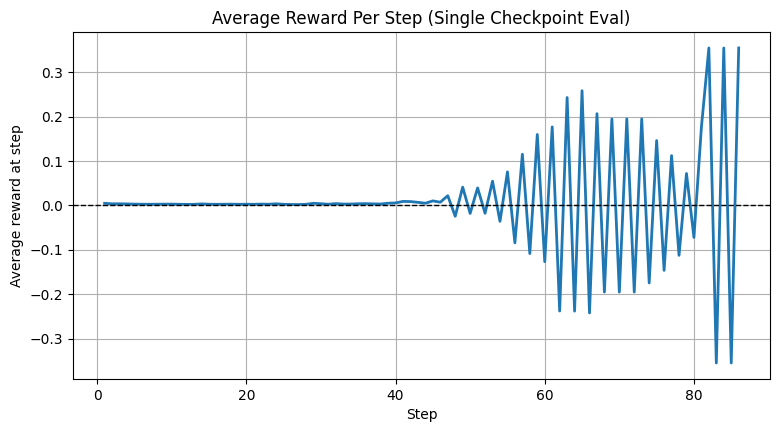

Plotted 86 steps. Last-step sample count: 1


In [19]:
# --------------------------
# Single-checkpoint test
# --------------------------
dataset_path = "tet_dataset_grid125_sigma1e-02_N2000_test.mat"
ckpt_path = "out/03-22-16-26/model_round179.pt"

num_test = 10
seed = 0

score_mode = "softmin"   # "softmin" or "worstk"
softmin_tau = 0.05
worstk_k = 10

patience_eval = 20
max_steps = 150
greedy = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

# Load dataset
ds = TetMat73Dataset(dataset_path, load_all=False)
print("dataset size:", ds.num_samples)
T_good = ds.T_good

rng = np.random.default_rng(seed)
test_ids = rng.integers(0, ds.num_samples, size=num_test)

# Evaluate one model
result = evaluate_checkpoint(
    ckpt_path,
    ds,
    test_ids,
    T_good,
    device,
    tet_quality_mode=tet_quality_mode,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
)

print()
print("bad_mean  final_mean best_mean  good_mean  improve_best  gap_to_good  steps_mean")
print(
    f"{result['bad_mean']:+.6f}  "
    f"{result['final_mean']:+.6f}  "
    f"{result['best_mean']:+.6f}  "
    f"{result['good_mean']:+.6f}  "
    f"{result['improve_best']:+.6f}  "
    f"{result['gap_to_good']:+.6f}  "
    f"{result['steps_mean']:.2f}"
)

# Plot average reward at each step index across test samples
step_reward_mean = result["step_reward_mean"]
step_reward_count = result["step_reward_count"]

if step_reward_mean.size == 0:
    print("No step rewards to plot (agent took 0 actions on all test samples).")
else:
    x = np.arange(1, step_reward_mean.size + 1)
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, step_reward_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True)
    plt.xlabel("Step")
    plt.ylabel("Average reward at step")
    plt.title("Average Reward Per Step (Single Checkpoint Eval)")
    plt.show()

    print(f"Plotted {step_reward_mean.size} steps. Last-step sample count: {int(step_reward_count[-1])}")

ds.close()


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
episode_id: 5
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio

Episode summary
steps=74  best_step=53  final_score=+0.426181  best_score=+0.735717

Action trace (one line per step):
step | op_type      | local_idx | env_action | model_action | valid | delta_score
   0 | edge (3-2)   |       177 |       1147 |          177 | True  | +0.005345
   1 | edge (3-2)   |       372 |       1340 |          372 | True  | +0.005320
   2 | edge (3-2)   |        85 |       1051 |           85 | True  | +0.004561
   3 | edge (3-2)   |       116 |       1080 |          116 | True  | +0.003630
   4 | edge (3-2)   |       384 |       1346 |          384 | True  | +0.004282
   5 | edge (3-2)   |       335 |       1295 |          335 | True  | +0.001922
   6 | edge (3-2)   |        79 |       1037 |           79 | True  | +0.002841
   7 | edge (3-2)   |        74 |

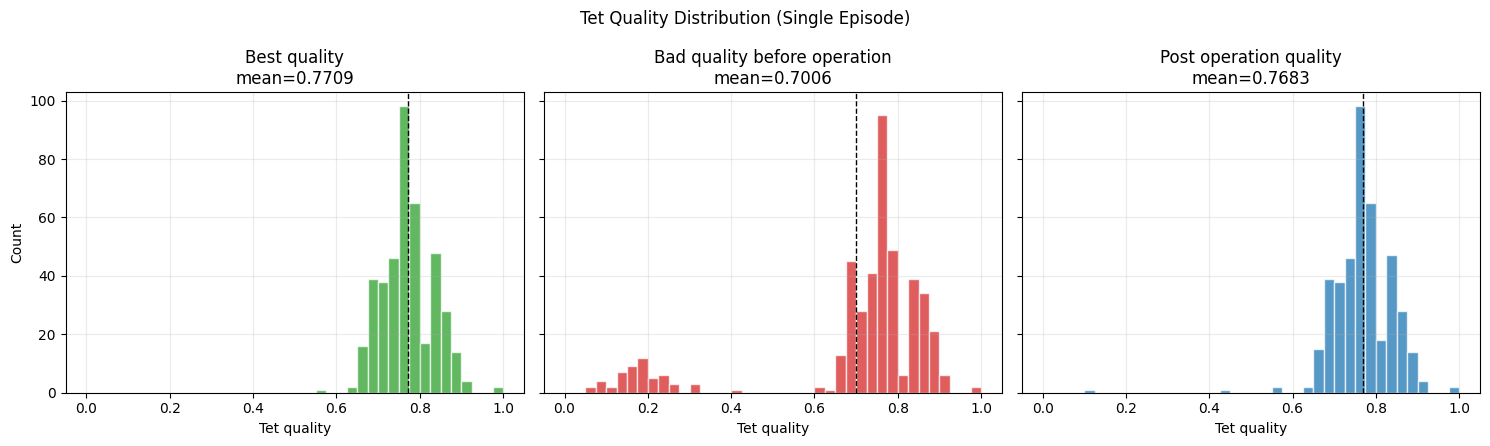

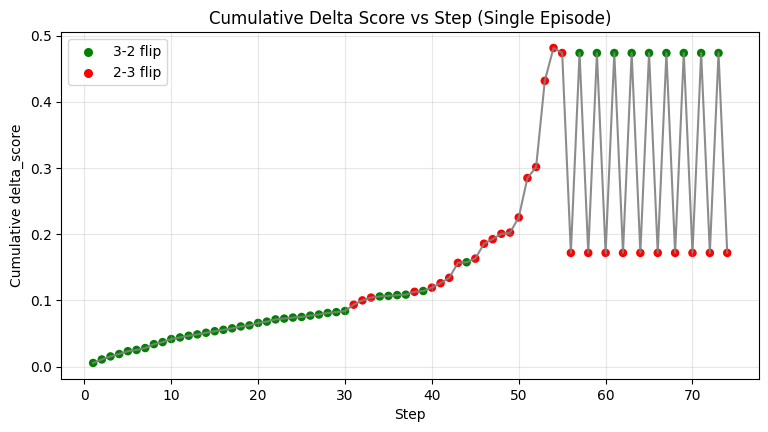

In [34]:
# -----------------------------------------
# Single-episode trace + quality histograms
# -----------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

episode_id = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("episode_id:", episode_id)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

ds = TetMat73Dataset(dataset_path, load_all=False)
if not (0 <= int(episode_id) < ds.num_samples):
    raise ValueError(f"episode_id must be in [0, {ds.num_samples-1}]")

P, Tbad = ds.get(int(episode_id))

topo0 = TetMeshTopology(P, Tbad, tet_quality_mode=tet_quality_mode)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

trace = run_agent_trace_episode(
    P,
    Tbad,
    model,
    device,
    tet_quality_mode=tet_quality_mode,
    score_mode=score_mode,
    softmin_tau=softmin_tau,
    worstk_k=worstk_k,
    patience_eval=patience_eval,
    max_steps=max_steps,
    greedy=greedy,
)

print()
print("Episode summary")
print(f"steps={trace['steps']}  best_step={trace['best_step']}  final_score={trace['final_score']:+.6f}  best_score={trace['best_score']:+.6f}")

print()
print("Action trace (one line per step):")
print("step | op_type      | local_idx | env_action | model_action | valid | delta_score")
for a in trace["action_log"]:
    print(
        f"{a['step']:4d} | {a['op_type']:<12} | {a['op_local_index']:9d} | "
        f"{a['env_action']:10d} | {a['model_action']:12d} | {str(a['valid']):5s} | {a['delta']:+.6f}"
    )

# Histograms: best / bad-before / post-operation
best_q = trace["best_q"]
bad_q = trace["bad_q"]
final_q = trace["final_q"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality", best_q, "tab:green"),
    ("Bad quality before operation", bad_q, "tab:red"),
    ("Post operation quality", final_q, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Single Episode)")
plt.tight_layout()
plt.show()

# Cumulative delta_score vs step (green: 3-2, red: 2-3)
action_log = trace["action_log"]
if len(action_log) == 0:
    print("No actions taken; skip cumulative delta_score plot.")
else:
    steps = np.arange(1, len(action_log) + 1)
    deltas = np.array([float(a["delta"]) for a in action_log], dtype=np.float64)
    cum_delta = np.cumsum(deltas)

    colors = ["green" if "3-2" in a["op_type"] else "red" for a in action_log]

    plt.figure(figsize=(9, 4.5))
    plt.plot(steps, cum_delta, color="gray", linewidth=1.5, alpha=0.9)
    plt.scatter(steps, cum_delta, c=colors, s=26)

    plt.scatter([], [], c="green", s=30, label="3-2 flip")
    plt.scatter([], [], c="red", s=30, label="2-3 flip")

    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Cumulative delta_score")
    plt.title("Cumulative Delta Score vs Step (Single Episode)")
    plt.legend()
    plt.show()

ds.close()


In [ ]:
# -------------------------------------------------
# Multi-episode aggregate histograms + avg cum score
# -------------------------------------------------
dataset_path = locals().get("dataset_path", "tet_dataset_grid125_sigma1e-02_N2000.mat")
ckpt_path = locals().get("ckpt_path", "out/03-22-16-26/model_round179.pt")

num_eval_episodes = 500
seed_multi = 123
episode_ids = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint:", ckpt_path)
print("num_eval_episodes:", num_eval_episodes)

if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

# Read tet quality metric from train config (fallback mean_ratio)
tet_quality_mode = resolve_quality_mode_from_ckpt(ckpt_path, default_mode="mean_ratio")

ds = TetMat73Dataset(dataset_path, load_all=False)

if episode_ids is None:
    rng = np.random.default_rng(seed_multi)
    replace = num_eval_episodes > ds.num_samples
    episode_ids = rng.choice(ds.num_samples, size=num_eval_episodes, replace=replace)
else:
    episode_ids = np.asarray(episode_ids, dtype=np.int64)

first_id = int(episode_ids[0])
P0, Tbad0 = ds.get(first_id)
topo0 = TetMeshTopology(P0, Tbad0, tet_quality_mode=tet_quality_mode)
model = build_model_from_ckpt(
    ckpt_path,
    device,
    obs_from_topo(
        topo0,
        step=0,
        no_improve=0,
        max_steps=max_steps,
        patience_eval=patience_eval,
    ),
)

all_bad_q = []
all_best_q = []
all_final_q = []
cum_trajs = []

for eid in tqdm(episode_ids, desc="Aggregate eval", leave=False):
    P, Tbad = ds.get(int(eid))
    tr = run_agent_trace_episode(
        P,
        Tbad,
        model,
        device,
        tet_quality_mode=tet_quality_mode,
        score_mode=score_mode,
        softmin_tau=softmin_tau,
        worstk_k=worstk_k,
        patience_eval=patience_eval,
        max_steps=max_steps,
        greedy=greedy,
    )

    all_bad_q.append(tr["bad_q"])
    all_best_q.append(tr["best_q"])
    all_final_q.append(tr["final_q"])

    deltas = np.array([float(a["delta"]) for a in tr["action_log"]], dtype=np.float64)
    cum = np.cumsum(deltas) if deltas.size > 0 else np.zeros((0,), dtype=np.float64)
    cum_trajs.append(cum)

bad_q_all = np.concatenate(all_bad_q) if len(all_bad_q) > 0 else np.zeros((0,), dtype=np.float64)
best_q_all = np.concatenate(all_best_q) if len(all_best_q) > 0 else np.zeros((0,), dtype=np.float64)
final_q_all = np.concatenate(all_final_q) if len(all_final_q) > 0 else np.zeros((0,), dtype=np.float64)

print()
print("Aggregate quality stats")
print(f"episodes={len(episode_ids)}")
print(f"bad_mean={bad_q_all.mean():.6f}  best_mean={best_q_all.mean():.6f}  final_mean={final_q_all.mean():.6f}")

fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
bins = np.linspace(0.0, 1.0, 41)

specs = [
    ("Best quality (all episodes)", best_q_all, "tab:green"),
    ("Bad quality before operation (all episodes)", bad_q_all, "tab:red"),
    ("Post operation quality (all episodes)", final_q_all, "tab:blue"),
]

for ax, (title, q, color) in zip(axs, specs):
    ax.hist(q, bins=bins, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(float(np.mean(q)), color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}\nmean={np.mean(q):.4f}")
    ax.set_xlabel("Tet quality")

axs[0].set_ylabel("Count")
fig.suptitle("Tet Quality Distribution (Aggregated Across Episodes)")
plt.tight_layout()
plt.show()

max_len = max((len(c) for c in cum_trajs), default=0)
if max_len == 0:
    print("No actions taken in all selected episodes; skip cumulative plot.")
else:
    cum_mean = np.full(max_len, np.nan, dtype=np.float64)
    cum_count = np.zeros(max_len, dtype=np.int64)
    for t in range(max_len):
        vals = [c[t] for c in cum_trajs if t < len(c)]
        if vals:
            cum_mean[t] = float(np.mean(vals))
            cum_count[t] = int(len(vals))

    x = np.arange(1, max_len + 1)
    plt.figure(figsize=(9.5, 4.8))
    plt.plot(x, cum_mean, "-", linewidth=2)
    plt.axhline(0.0, color="k", linestyle="--", linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Step")
    plt.ylabel("Average cumulative delta_score")
    plt.title("Average Cumulative Score Change vs Step (Aggregated Episodes)")
    plt.show()

    print(f"Cumulative curve length: {max_len} steps")
    print(f"Last-step contributor count: {int(cum_count[-1])}")

ds.close()


device: cpu
checkpoint: out/03-22-16-26/model_round179.pt
num_eval_episodes: 500
Loaded train config: /Users/wanzhoulei/Desktop/3d-meshing-run/out/03-22-16-26/train_config.json
Using tet quality metric: mean_ratio


Aggregate eval:   0%|          | 0/500 [00:00<?, ?it/s]

In [31]:
# -------------------------------------------------
# Min tet-quality summary across evaluated episodes
# -------------------------------------------------
# Requires that the previous multi-episode cell has been run and produced
# all_bad_q / all_final_q lists (one array per episode).

if "all_bad_q" not in locals() or "all_final_q" not in locals():
    raise RuntimeError("Run the multi-episode evaluation cell first (it defines all_bad_q and all_final_q).")

if len(all_bad_q) == 0 or len(all_final_q) == 0:
    print("No episode traces available.")
else:
    min_bad_per_ep = np.array([float(np.min(q)) for q in all_bad_q], dtype=np.float64)
    min_final_per_ep = np.array([float(np.min(q)) for q in all_final_q], dtype=np.float64)
    min_best_per_ep = np.array([float(np.min(q)) for q in all_best_q], dtype=np.float64)

    print("Average min tet quality before RL :", f"{min_bad_per_ep.mean():.6f}")
    print("Average min tet quality for best  :", f"{min_best_per_ep.mean():.6f}")
    print("Average min tet quality after RL  :", f"{min_final_per_ep.mean():.6f}")
    print("Average improvement in min quality:", f"{(min_final_per_ep - min_bad_per_ep).mean():+.6f}")
    print("Gap to best                       :", f"{(min_final_per_ep - min_best_per_ep).mean():+.6f}")



Average min tet quality before RL : 0.035373
Average min tet quality for best  : 0.603174
Average min tet quality after RL  : 0.539413
Average improvement in min quality: +0.504040
Gap to best                       : -0.063761
